# What's using the CBRS band? A two-month look at shared-spectrum sensor data

**Data:** NASCTN CBRS Sharing Ecosystem Assessment (SEA) sensors, March–April 2025. The documentation is [NIST TN 2359](https://doi.org/10.6028/NIST.TN.2359).
**Goal:** Turn about 5 million radio measurements into a clear picture of who uses the 3.55–3.7 GHz band, and when. Then test whether *cheap summary statistics alone* can tell different kinds of transmitters apart.

### TL;DR
* **The data are trustworthy and physically consistent.** Receiver-noise statistics match textbook theory (mean − median = 1.56 dB measured vs 1.59 dB predicted). The noise floor, about −98 dBm per 10 MHz, matches the sensors' own calibration to within a few tenths of a dB.
* **Three data problems were caught before they could corrupt results.** Two are errors in the documented raw-file layout: each channel is 5,561 values, not 5,560, and the frame-power blocks are in reverse order. The third is a sensor artifact: the top two channels have a noise floor 6–18 dB higher than the rest.
* **Commercial 4G/5G use dominates the band.** At most sites, more than 95% of in-band measurements are above the noise, with a clear daily cycle: 0.5–1.3 dB louder in the afternoon.
* **An unsupervised model using only three cheap summary features separates noise, commercial signals and impulsive (radar-like) activity.** The raw data confirm it independently: 92–95% of the signal clusters carry the 5 ms frame rhythm of 4G/5G, vs 0.15% of the impulsive cluster. Impulsive activity is concentrated below the commercial band and at coastal sites, and peaks at Catalina Island (17% of captures).
* **San Diego's Midway sensor got louder from March to April** (+2.1 dB, 95% CI 1.3–2.9 dB), and so did Catalina's directional antenna (+1.7 dB).

### Roadmap
| # | Step | Skill it demonstrates |
|---|------|------------------------|
| 1 | A 5-minute primer on CBRS and the sensors | Explaining the domain |
| 2 | Load, clean and audit the monthly summaries | Automated data workflow, data integrity |
| 3 | Check the measurements against physics | Statistical rigor |
| 4 | Explore: where, when and how busy is the band? | EDA and visualization |
| 5 | Classify each measurement with an unsupervised model | Machine learning |
| 6 | Open the raw sensor files and independently validate the model | Signal processing, data integrity |
| 7 | Did anything change from March to April? | Statistical inference |
| 8 | Conclusions, limitations and next steps | Written communication |

In [1]:
import io, json, lzma, tarfile, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

DATA = Path("data")
SEED = 0

# One consistent look for every figure: quiet axes and grid, one blue ramp for magnitude.
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#184f95", "#0d366b"])
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 11, "legend.frameon": False,
})
pd.set_option("display.precision", 2)

## 1. A 5-minute primer

**The band.** The *Citizens Broadband Radio Service* (CBRS) is 150 MHz of radio spectrum, from 3550 to 3700 MHz. It is the first U.S. band that commercial users *share* with the military, under three tiers:

| Tier | Who | Rule |
|---|---|---|
| 1. Incumbents | Mostly Navy radars (ship-borne, near the coasts) | Always have priority |
| 2. Priority Access License (PAL) | Carriers who bought licenses at auction | Protected from tier 3 |
| 3. General Authorized Access (GAA) | Anyone with certified equipment | Uses whatever is left |

The commercial radios are called **CBSDs** (CBRS devices). Most are 4G/5G base stations. A cloud service, the **Spectrum Access System (SAS)**, tells each CBSD which channels and power it may use. Coastal sensor networks, the **Environmental Sensing Capability (ESC)**, watch for radar. When a radar shows up near a coastal **Dynamic Protection Area (DPA)**, the SAS moves CBSDs out of the way. NASCTN's SEA program places *independent* sensors near those DPAs to check that this sharing works.

**What one sensor does.** The sensor steps through **18 channels, each 10 MHz wide**, centered at 3535, 3545, …, 3705 MHz. That covers 3530–3710 MHz, a little wider than the CBRS band on both sides. It listens to each channel for **4 seconds**, recording 56 million samples at 14 MHz. It then computes statistics on the spot and moves on. One full sweep takes about 90 s, and the sensor repeats sweeps all day. Two channels sit *outside* the band. They make useful controls:

* **3535 and 3545 MHz** are below CBRS, so no CBSD may transmit there. Energy there is *not* commercial.
* **3695 and 3705 MHz** sit at the very top of the range. As Section 3 shows, the sensor's own filter makes these two channels unreliable, so we set them aside.

**Decibels in 30 seconds.** Radio power spans many orders of magnitude, so it's measured on a log scale. **dBm** means decibels relative to 1 milliwatt: 0 dBm = 1 mW, and −100 dBm = 10⁻¹³ W. Differences in **dB** are ratios: **+3 dB ≈ 2×, +10 dB = 10×, +20 dB = 100×.** A reading of −98 dBm is close to the faintest thing these sensors can hear.

**The sensors in this dataset** (from Table 1 of the manual):

In [2]:
SENSORS = pd.DataFrame([
    ("NIT",                  "Norfolk International Terminal, VA",        "East coast", "US/Eastern"),
    ("HU",                   "Hampton University tower, VA",              "East coast", "US/Eastern"),
    ("CBBT-Omni",            "Chesapeake Bay Bridge-Tunnel, VA (omni)",   "East coast", "US/Eastern"),
    ("CBBT-Directional",     "Chesapeake Bay Bridge-Tunnel, VA (15° panel)", "East coast", "US/Eastern"),
    ("Midway",               "USS Midway Museum, San Diego, CA",          "West coast", "US/Pacific"),
    ("Catalina-Omni",        "Mt Orizaba, Catalina Island, CA (omni)",    "West coast", "US/Pacific"),
    ("Catalina-Directional", "Mt Orizaba, Catalina Island, CA (15° panel)", "West coast", "US/Pacific"),
    ("GMM",                  "Green Mountain Mesa, Boulder, CO (no DPA: control site)", "Colorado", "US/Mountain"),
], columns=["sensor", "location", "region", "tz"]).set_index("sensor")
SENSOR_ORDER = list(SENSORS.index)
SENSORS

,location,region,tz
sensor,,,
NIT,"Norfolk International Terminal, VA",East coast,US/Eastern
HU,"Hampton University tower, VA",East coast,US/Eastern
CBBT-Omni,"Chesapeake Bay Bridge-Tunnel, VA (omni)",East coast,US/Eastern
CBBT-Directional,"Chesapeake Bay Bridge-Tunnel, VA (15° panel)",East coast,US/Eastern
Midway,"USS Midway Museum, San Diego, CA",West coast,US/Pacific
Catalina-Omni,"Mt Orizaba, Catalina Island, CA (omni)",West coast,US/Pacific
Catalina-Directional,"Mt Orizaba, Catalina Island, CA (15° panel)",West coast,US/Pacific
GMM,"Green Mountain Mesa, Boulder, CO (no DPA: cont...",Colorado,US/Mountain


## 2. Load, clean and audit the monthly summaries

The program publishes one **summary CSV per month**. Each row is **one 4-second listen on one channel by one sensor**, reduced to three numbers:

* `mean`: average power during the 4 s (dBm)
* `median`: median power during the 4 s (dBm)
* `max`: the single strongest instant during the 4 s (dBm)

Each row also carries an `overload` flag, which means the receiver was momentarily driven past its limit.

The loader below is a small, repeatable function, not a series of ad-hoc cells. It reads only the columns we need, stores repeated strings as categories to save memory, and parses timestamps as UTC. Next month's file can go through exactly the same step.

In [3]:
COLS = ["sensor_name", "channel_frequency_mhz", "timestamp", "acquisition_timestamp",
        "max", "median", "mean", "overload"]

def load_summaries(paths):
    frames = [pd.read_csv(p, usecols=COLS, dtype={"sensor_name": "category"}).assign(source=p.name)
              for p in paths]
    df = pd.concat(frames, ignore_index=True)
    df = df.rename(columns={"sensor_name": "sensor", "channel_frequency_mhz": "freq_mhz",
                            "timestamp": "time", "acquisition_timestamp": "sweep_time"})
    df["sensor"] = pd.Categorical(df["sensor"], categories=SENSOR_ORDER)
    df["source"] = df["source"].astype("category")
    for c in ["time", "sweep_time"]:
        df[c] = pd.to_datetime(df[c], format="ISO8601", utc=True)
    return df

raw_summary = load_summaries(sorted(DATA.glob("2025_0*.csv")))
print(f"{len(raw_summary):,} rows, {raw_summary.memory_usage(deep=True).sum() / 1e6:.0f} MB in memory")
raw_summary.head()

5,244,408 rows, 267 MB in memory


,sensor,freq_mhz,time,sweep_time,max,median,mean,overload,source
0,Midway,3535.0,2025-02-28 17:01:08.960000+00:00,2025-02-28 17:01:08.960000+00:00,-82.88,-98.76,-97.13,False,2025_03.csv
1,Midway,3545.0,2025-02-28 17:01:13.548000+00:00,2025-02-28 17:01:08.960000+00:00,-85.01,-99.32,-97.70,False,2025_03.csv
2,Midway,3555.0,2025-02-28 17:01:18.251000+00:00,2025-02-28 17:01:08.960000+00:00,-84.32,-99.13,-97.50,False,2025_03.csv
3,Midway,3565.0,2025-02-28 17:01:24.648000+00:00,2025-02-28 17:01:08.960000+00:00,-50.35,-80.57,-70.88,False,2025_03.csv
4,Midway,3575.0,2025-02-28 17:01:29.373000+00:00,2025-02-28 17:01:08.960000+00:00,-52.66,-87.19,-72.26,False,2025_03.csv


### Data-integrity audit

Before analyzing anything, we check the data against what it *should* look like:

1. **Missing values.** There should be none.
2. **Duplicates.** Each (sensor, sweep, channel) should appear once. Monthly files are cut by *file date*, and a sensor's "day" file can begin before midnight UTC, so neighboring months overlap in time and could double-count.
3. **Complete sweeps.** Every sweep should contain all 18 channels.
4. **Time coverage.** Rows outside the two months we're studying should be trimmed.

In [4]:
print("Missing values:", raw_summary.isna().sum().sum())
print(raw_summary.groupby("source", observed=True)["time"].agg(["min", "max"]))

key = ["sensor", "sweep_time", "freq_mhz"]
dupes = raw_summary.duplicated(key, keep="first")
print(f"\nDuplicate (sensor, sweep, channel) rows: {dupes.sum():,}")

Missing values: 0
                                         min                              max
source                                                                       
2025_03.csv 2025-02-28 17:01:08.960000+00:00 2025-04-01 00:00:40.934000+00:00
2025_04.csv 2025-03-31 18:01:01.287000+00:00 2025-05-01 00:01:32.022000+00:00



Duplicate (sensor, sweep, channel) rows: 0


In [5]:
df = raw_summary.loc[~dupes].copy()

per_sweep = df.groupby(["sensor", "sweep_time"], observed=True).size()
print("Channels per sweep:", per_sweep.value_counts().to_dict())

in_window = df["time"].between("2025-03-01", "2025-05-01", inclusive="left")
print(f"Rows outside Mar–Apr 2025 (dropped): {(~in_window).sum():,}")
df = df.loc[in_window].reset_index(drop=True)
df["month"] = df["time"].dt.strftime("%Y-%m")
print(f"Clean table: {len(df):,} rows")

Channels per sweep: {18: 291356}
Rows outside Mar–Apr 2025 (dropped): 4,302


Clean table: 5,240,106 rows


**What we found.** The files overlap in *time*: the April file begins on the evening of 31 March. They don't overlap in *content*, though. Each capture appears exactly once, so nothing is double-counted. The March file also starts with a few hours from 28 February, which we trim. Every sweep has all 18 channels.

### How complete is each sensor's record?

A quick heatmap of sweeps per day shows any outages. Gaps matter later: an "empty" hour could be a quiet band, or just a sensor that was offline.

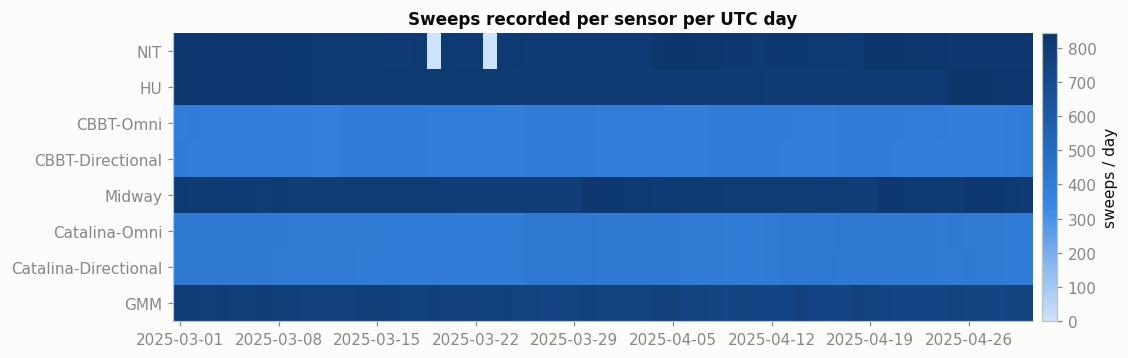

Typical sweeps per day: {'NIT': 816, 'HU': 809, 'CBBT-Omni': 393, 'CBBT-Directional': 393, 'Midway': 798, 'Catalina-Omni': 412, 'Catalina-Directional': 411, 'GMM': 757}
Sensor-days with < 50% of the usual sweeps: [('NIT', '2025-03-19', 0), ('NIT', '2025-03-23', 0)]


In [6]:
daily = (df.drop_duplicates(["sensor", "sweep_time"])
           .groupby(["sensor", df["time"].dt.date], observed=True).size()
           .unstack(fill_value=0).reindex(SENSOR_ORDER))

fig, ax = plt.subplots(figsize=(12, 3.4))
im = ax.imshow(daily.values, aspect="auto", cmap=BLUES, vmin=0, interpolation="none")
ax.set_yticks(range(len(daily)), daily.index)
ticks = np.arange(0, daily.shape[1], 7)
ax.set_xticks(ticks, [str(daily.columns[i]) for i in ticks])
ax.grid(False)
ax.set_title("Sweeps recorded per sensor per UTC day")
fig.colorbar(im, ax=ax, label="sweeps / day", pad=0.01)
plt.show()

print("Typical sweeps per day:", daily.median(axis=1).astype(int).to_dict())
gaps = daily.lt(0.5 * daily.median(axis=1), axis=0).stack()
print("Sensor-days with < 50% of the usual sweeps:",
      [(s, str(d), int(daily.loc[s, d])) for s, d in gaps[gaps].index])

Single-antenna sensors log about 800 sweeps a day (one every ~108 s). **Dual-antenna sites (CBBT, Catalina) log about half as many per antenna**, because the sensor alternates between its omni and directional antennas. That is by design, not missing data. The only real gaps are **two days in mid-March when NIT recorded nothing**. Everything else is essentially complete. Two missing days out of 61 won't bias month-level statistics, but it's worth knowing before reading any NIT time series.

### The overload flag

`overload = True` means the receiver's analog-to-digital converter clipped at least once during the 4 s. Clipped captures have unreliable power statistics, so we **report how often it happens and then exclude those rows** from the statistics.

In [7]:
overload_rate = (df.groupby(["sensor"], observed=True)["overload"].mean() * 100).round(2)
print("Overloaded captures (% of rows):")
print(overload_rate.to_string())

clean = df.loc[~df["overload"]].copy()
print(f"\nKept {len(clean):,} of {len(df):,} rows ({len(clean) / len(df):.1%})")

Overloaded captures (% of rows):
sensor
NIT                     1.18
HU                      0.52
CBBT-Omni               1.75
CBBT-Directional        1.06
Midway                  4.57
Catalina-Omni           2.42
Catalina-Directional    0.40
GMM                     0.00



Kept 5,160,200 of 5,240,106 rows (98.5%)


## 3. Do the measurements obey physics? (sanity checks before any modelling)

A good first move with instrument data is to check it against a case where we know the answer. That case is **pure receiver noise**: a channel where nothing is transmitting.

Thermal noise has well-known statistics. Its instantaneous power follows an **exponential distribution**, which leads to two predictions we can test:

1. **Mean − median.** For an exponential distribution, median = ln 2 × mean. In dB the gap is 10·log₁₀(1/ln 2) = **1.59 dB**. Any real signal on top of the noise makes the distribution lumpier and widens the gap.
2. **Max − mean** (the *crest factor*). The largest of *N* independent exponential samples is about (ln *N* + 0.577) × mean. With *N* = 56 million samples per capture, that comes to **≈ 12.7 dB**. Pulsed signals like radar have far higher crest factors.

We define these two features for every capture:

In [8]:
clean["gap"] = clean["mean"] - clean["median"]      # mean − median, dB
clean["crest"] = clean["max"] - clean["mean"]       # max − mean, dB

N = 4 * 14e6                                         # samples in one 4 s capture
GAP_NOISE = 10 * np.log10(1 / np.log(2))
CREST_NOISE = 10 * np.log10(np.log(N) + 0.5772)
print(f"Theory for pure noise: gap = {GAP_NOISE:.2f} dB, crest ≈ {CREST_NOISE:.1f} dB")
print(f"Observed 1st percentile: gap = {clean['gap'].quantile(0.01):.2f} dB, "
      f"crest = {clean['crest'].quantile(0.01):.2f} dB")

Theory for pure noise: gap = 1.59 dB, crest ≈ 12.7 dB


Observed 1st percentile: gap = 1.56 dB, crest = 12.38 dB


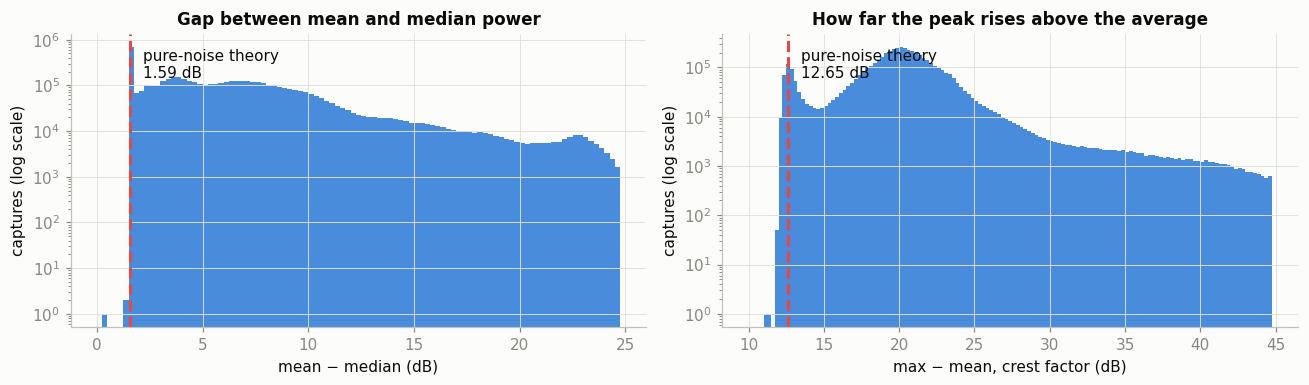

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col, ref, rng, label in [
    (axes[0], "gap", GAP_NOISE, (0, 25), "mean − median (dB)"),
    (axes[1], "crest", CREST_NOISE, (10, 45), "max − mean, crest factor (dB)")]:
    ax.hist(clean[col], bins=np.arange(*rng, 0.25), color=BLUE, alpha=0.85)
    ax.axvline(ref, color=RED, lw=2, ls="--")
    ax.annotate(f"pure-noise theory\n{ref:.2f} dB", (ref, 0.95), xycoords=("data", "axes fraction"),
                xytext=(8, 0), textcoords="offset points", va="top", color=INK)
    ax.set_xlabel(label); ax.set_yscale("log"); ax.set_ylabel("captures (log scale)")
axes[0].set_title("Gap between mean and median power")
axes[1].set_title("How far the peak rises above the average")
plt.tight_layout(); plt.show()

Both histograms have a **hard left edge where theory puts it**. No capture can be "quieter than noise", and a large pile of captures sits right at the noise values. The small differences are explainable:
* The gap edge reads 1.56 dB rather than 1.59 because the values are stored as 16-bit floats with 1/16 dB resolution.
* The crest edge sits a few tenths of a dB below 12.7 because neighboring samples aren't fully independent after the sensor's 10 MHz filter. That makes the effective *N* somewhat smaller.

Everything to the right of those edges is *signal*.

### Estimating each sensor's noise floor

To say whether a channel is "busy" we need a baseline: the **noise floor**, the average power a sensor reads when nothing is transmitting. Physics predicts it too. A resistor at room temperature produces −174 dBm per Hz of bandwidth, which is −104 dBm across 10 MHz. The receiver then adds its own noise, measured by its **noise figure** (NF):

$$P_\text{floor} = -174 + 10\log_{10}(10^7) + \text{NF} = -104\ \text{dBm} + \text{NF}$$

For the empirical estimate we take captures that *look* like pure noise (gap < 1.7 dB and crest < 15 dB) in the two out-of-band channels, where CBSDs aren't allowed. The median of their mean power is the floor.

In [10]:
KTB = -174 + 10 * np.log10(10e6)
noise_like = clean[(clean["gap"] < 1.7) & (clean["crest"] < 15) & clean["freq_mhz"].isin([3535, 3545])]
floor_tbl = (noise_like.groupby("sensor", observed=True)["mean"]
             .agg(noise_floor_dbm="median", spread_iqr=lambda s: s.quantile(.75) - s.quantile(.25),
                  n_captures="size"))
floor_tbl["implied_NF_dB"] = floor_tbl["noise_floor_dbm"] - KTB
FLOOR = floor_tbl["noise_floor_dbm"]
floor_tbl

,noise_floor_dbm,spread_iqr,n_captures,implied_NF_dB
sensor,,,,
NIT,-99.25,0.38,82723,4.75
HU,-98.94,0.38,56890,5.06
CBBT-Omni,-98.44,1.25,39040,5.56
CBBT-Directional,-98.50,1.25,42235,5.50
Midway,-97.26,0.57,63543,6.74
Catalina-Omni,-98.19,0.81,27914,5.81
Catalina-Directional,-98.62,0.81,25927,5.38
GMM,-98.69,0.81,47313,5.31


Every sensor's floor lands between −97 and −99.3 dBm, with a spread (IQR) of about 1 dB or less within each sensor. The implied noise figures of 5–7 dB are typical for a field receiver with a preamplifier.

### Cross-check against the sensor's own calibration

The sensors calibrate themselves regularly against a built-in noise source and store the resulting **noise figure for every channel** in the raw-file metadata. We'll open raw files properly in Section 6. For now we just peek at the metadata of one Catalina-Omni sweep. This check turned out to matter more than expected:

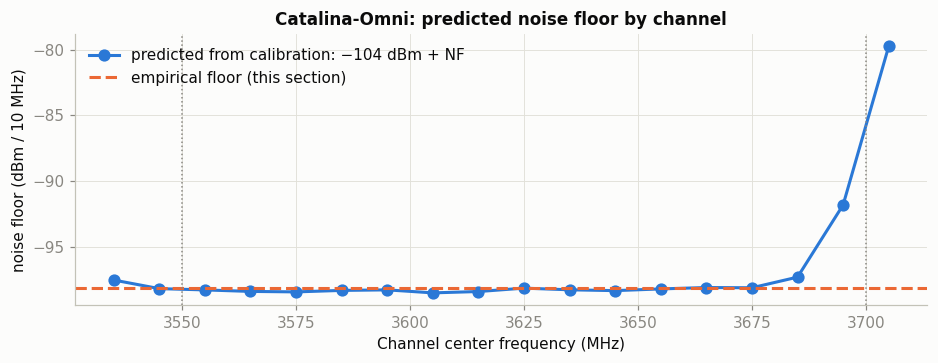

{3535.0: 6.4, 3545.0: 5.8, 3555.0: 5.7, 3565.0: 5.6, 3575.0: 5.5, 3585.0: 5.7, 3595.0: 5.7, 3605.0: 5.5, 3615.0: 5.6, 3625.0: 5.8, 3635.0: 5.7, 3645.0: 5.6, 3655.0: 5.8, 3665.0: 5.9, 3675.0: 5.9, 3685.0: 6.7, 3695.0: 12.2, 3705.0: 24.2}


In [11]:
def read_sigmf(buf):
    # One .sigmf file (a tar archive) -> (metadata dict, numeric array as float32)
    with tarfile.open(fileobj=io.BytesIO(buf)) as tar:
        for m in tar.getmembers():
            if m.name.endswith(".sigmf-meta"):
                meta = json.load(tar.extractfile(m))
            elif m.name.endswith(".sigmf-data"):
                data = tar.extractfile(m).read()
    return meta, np.frombuffer(lzma.decompress(data), dtype=np.float16).astype(np.float32)

with zipfile.ZipFile(DATA / "2025-03-02_Catalina-Omni.zip") as z:
    first = sorted(n for n in z.namelist() if n.endswith(".sigmf"))[0]
    meta, arr = read_sigmf(z.read(first))

cal = pd.DataFrame({"freq_mhz": [c["core:frequency"] / 1e6 for c in meta["captures"]],
                    "noise_figure_db": [c["ntia-sensor:sensor_calibration"]["noise_figure"] for c in meta["captures"]]})
cal["predicted_floor_dbm"] = KTB + cal["noise_figure_db"]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(cal["freq_mhz"], cal["predicted_floor_dbm"], "o-", color=BLUE, lw=2, ms=7, label="predicted from calibration: −104 dBm + NF")
ax.axhline(FLOOR["Catalina-Omni"], color=ORANGE, ls="--", lw=2, label="empirical floor (this section)")
ax.axvline(3550, color=MUTED, lw=1, ls=":"); ax.axvline(3700, color=MUTED, lw=1, ls=":")
ax.set_xlabel("Channel center frequency (MHz)"); ax.set_ylabel("noise floor (dBm / 10 MHz)")
ax.set_title("Catalina-Omni: predicted noise floor by channel"); ax.legend(loc="upper left")
plt.show()
print(cal.set_index("freq_mhz")["noise_figure_db"].round(1).to_dict())

Two results:

1. **Across 3535–3685 MHz the calibrated noise figure is flat**, and the predicted floor agrees with our purely statistical estimate to within a few tenths of a dB. Two independent methods give the same baseline.
2. **The top two channels are different.** At 3695 and 3705 MHz the noise figure jumps to about 12 and 24 dB. Those channels sit on the edge of the sensor's own band-pass filter, which protects the receiver from strong signals outside CBRS. Their noise floor is 6–18 dB higher, so a "loud" reading there may be nothing but the receiver's own noise. Compared naïvely with the other channels, they would look permanently busy.

**Decision:** we leave 3695 and 3705 MHz out of all comparisons below. We only have calibration metadata for Catalina, but the SEA sensors share one design, so we apply the same rule everywhere and note it as an assumption. Catching this kind of thing is why you check the instrument before interpreting the data.

With a floor for each sensor we can define the key quantity for the rest of the notebook:

> **excess = mean power − noise floor** (dB): how far above "empty" a channel was during a capture.

In [12]:
clean = clean[clean["freq_mhz"] <= 3685].copy()          # drop the two filter-edge channels
clean["excess"] = clean["mean"] - clean["sensor"].map(FLOOR).astype(float)
clean["in_band"] = clean["freq_mhz"] >= 3555             # inside CBRS (3550–3690 MHz analysed)
CHANNELS = np.sort(clean["freq_mhz"].unique())
EDGES = np.append(CHANNELS - 5, CHANNELS[-1] + 5)        # channel boundaries, for heatmaps
print(f"{len(clean):,} captures on {len(CHANNELS)} channels ({CHANNELS[0]:.0f}–{CHANNELS[-1]:.0f} MHz)")

4,579,599 captures on 16 channels (3535–3685 MHz)


## 4. Exploring the band: where, and when?

### Where: how loud is each channel?

For each sensor and channel we take the **median excess**: how many dB above the noise floor a typical capture is. The dashed line marks the lower edge of the CBRS band. The small helper function draws this kind of sensor × channel map, and we reuse it later.

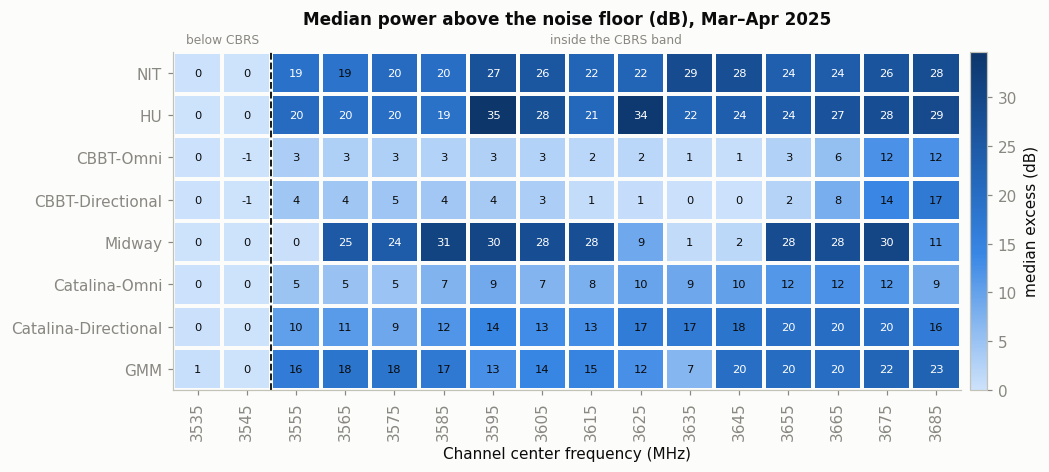

In-band captures more than 3 dB above the floor (%): {'NIT': 97, 'HU': 97, 'CBBT-Omni': 50, 'CBBT-Directional': 61, 'Midway': 84, 'Catalina-Omni': 97, 'Catalina-Directional': 99, 'GMM': 100}


In [13]:
def channel_heatmap(table, title, label, fmt="{:.0f}", vmin=0, vmax=None):
    vmax = vmax if vmax is not None else np.nanmax(table.values)
    fig, ax = plt.subplots(figsize=(11, 4))
    mesh = ax.pcolormesh(EDGES, np.arange(len(table) + 1), table.values, cmap=BLUES, vmin=vmin, vmax=vmax,
                         edgecolors=SURFACE, linewidth=1.5)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            v = table.iloc[i, j]
            txt = fmt.format(v)
            txt = fmt.format(0.0) if float(txt) == 0 else txt       # avoid printing "-0"
            ax.text(table.columns[j], i + 0.5, txt, ha="center", va="center", fontsize=7.5,
                    color="white" if v > vmin + 0.55 * (vmax - vmin) else INK)
    ax.axvline(3550, color=INK, ls="--", lw=1.2)
    ax.text(3540, -0.12, "below CBRS", ha="center", va="bottom", fontsize=8, color=MUTED)
    ax.text(3620, -0.12, "inside the CBRS band", ha="center", va="bottom", fontsize=8, color=MUTED)
    ax.set_yticks(np.arange(len(table)) + 0.5, table.index); ax.invert_yaxis(); ax.grid(False)
    ax.set_xticks(table.columns, [f"{f:.0f}" for f in table.columns], rotation=90)
    ax.set_xlabel("Channel center frequency (MHz)")
    ax.set_title(title, pad=18)
    fig.colorbar(mesh, ax=ax, label=label, pad=0.01)
    plt.show()

med_excess = clean.groupby(["sensor", "freq_mhz"], observed=True)["excess"].median().unstack()
channel_heatmap(med_excess, "Median power above the noise floor (dB), Mar–Apr 2025", "median excess (dB)")

busy = clean[clean["in_band"]].assign(b=lambda d: d["excess"] > 3).groupby("sensor", observed=True)["b"].mean() * 100
print("In-band captures more than 3 dB above the floor (%):", busy.round(0).astype(int).to_dict())

**Reading the map:**

* **Below the band (3535/3545 MHz) the median is 0 dB at every site.** Commercial devices stay out of these channels, as the rules require, and this also confirms the noise-floor estimate.
* **Inside CBRS, each site has its own fingerprint.**
  * Norfolk (NIT, HU) and Boulder (GMM) see strong signals, 15–35 dB above the floor, on nearly every channel.
  * San Diego (Midway) is loud except around 3555 and 3625–3645 MHz.
  * The Chesapeake Bay Bridge-Tunnel (CBBT), out on the water, and Catalina's omni antenna mostly see weak signals.

  These differences reflect how close each sensor sits to base stations and how operators have divided the band, which is exactly what the SAS coordinates.
* **A yes/no "occupied" metric would hide all of this.** The percentages printed under the map show that at most sites more than 95% of in-band captures sit above the 3 dB line. That metric is saturated, so the rest of the notebook works with excess power in dB.

### When: a waterfall view

A **waterfall** plots time down the page, frequency across it and power as color. Here is one week at Hampton University, showing both the average (`mean`) and peak (`max`) power.

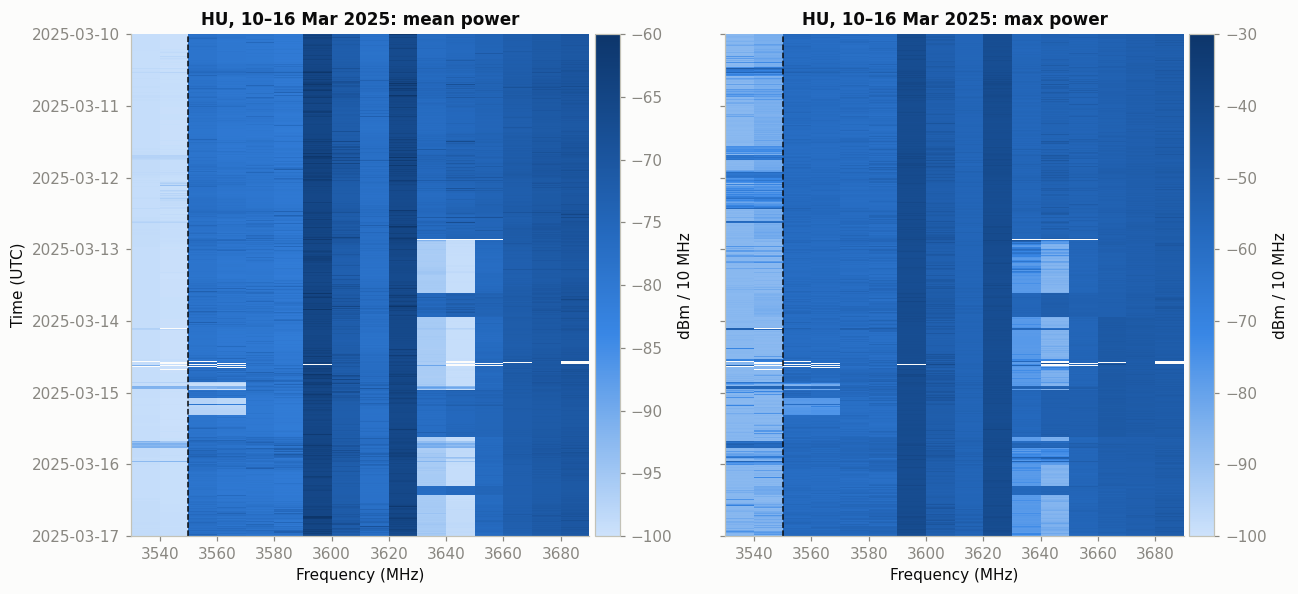

In [14]:
week = clean[(clean["sensor"] == "HU") & clean["time"].between("2025-03-10", "2025-03-17")]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
for ax, stat, vmax in [(axes[0], "mean", -60), (axes[1], "max", -30)]:
    wf = week.pivot_table(index="sweep_time", columns="freq_mhz", values=stat)
    m = ax.pcolormesh(wf.columns, wf.index, wf.values, shading="nearest", cmap=BLUES,
                      vmin=-100, vmax=vmax, rasterized=True)
    ax.axvline(3550, color=INK, ls="--", lw=1)
    ax.set_title(f"HU, 10–16 Mar 2025: {stat} power")
    ax.set_xlabel("Frequency (MHz)"); ax.grid(False)
    fig.colorbar(m, ax=ax, label="dBm / 10 MHz", pad=0.01)
axes[0].set_ylabel("Time (UTC)"); axes[0].invert_yaxis()
plt.tight_layout(); plt.show()

Two things stand out. (Thin white lines are the occasional missing sweep.)

* **Channels switching off together.** 3630–3650 MHz is normally busy, but it drops to near the floor for hours at a time on 13, 14, 15 and 16 March, then comes back. A coordinated shutdown of particular channels is what a SAS response to a DPA activation looks like: CBSDs moved off the channels an incumbent needs. Maintenance or reconfiguration could also explain it, and confirming it would take the activation logs.
* **Bursts below the band.** In the `max` panel, 3530–3550 MHz flickers with strong, short bursts while its `mean` stays at the floor. Something is transmitting short pulses where commercial devices aren't allowed. Section 5 comes back to this.

### When: time of day

Do commercial networks carry more traffic by day? For each sensor we average in-band excess power by **local hour**.

**A note on statistical rigor.** Consecutive sweeps are strongly correlated: a busy minute is followed by another busy minute. Treating millions of rows as independent would give absurdly narrow error bars. So we build a **bootstrap confidence interval by resampling whole days**. The day is the independent unit. Each day's profile is also centered on that day's own mean, so the plot shows the *shape* of the daily cycle rather than day-to-day level changes.

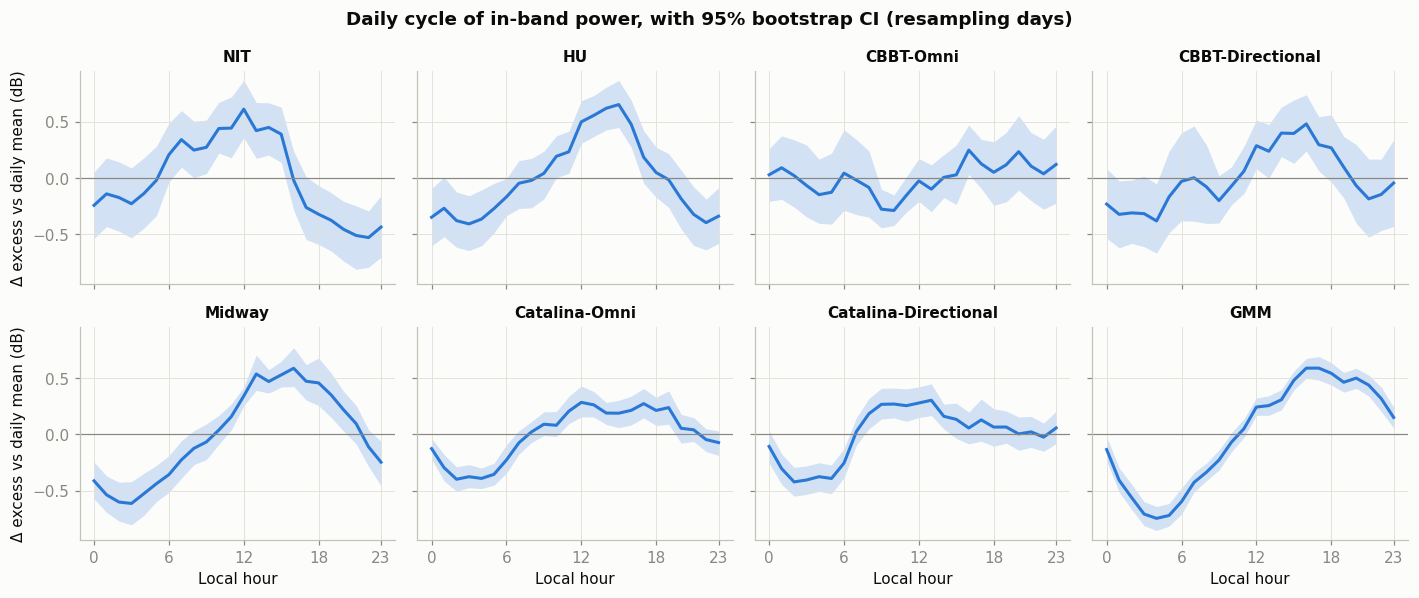

Peak-to-trough swing (dB): {'NIT': 1.14, 'HU': 1.06, 'CBBT-Omni': 0.54, 'CBBT-Directional': 0.86, 'Midway': 1.2, 'Catalina-Omni': 0.68, 'Catalina-Directional': 0.73, 'GMM': 1.33}


In [15]:
def bootstrap_mean(X, B=1000, seed=SEED):
    # Row-resampling bootstrap: X is (days × hours). Returns mean and 95% CI per column.
    rng = np.random.default_rng(seed)
    boots = np.stack([np.nanmean(X[rng.integers(0, len(X), len(X))], axis=0) for _ in range(B)])
    return np.nanmean(X, axis=0), np.nanpercentile(boots, [2.5, 97.5], axis=0)

inband = clean[clean["in_band"]]
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5), sharex=True, sharey=True)
swing = {}
for ax, s in zip(axes.flat, SENSOR_ORDER):
    d = inband[inband["sensor"] == s]
    local = d["time"].dt.tz_convert(SENSORS.loc[s, "tz"])       # convert UTC to the site's local time
    grid = d.groupby([local.dt.date.rename("day"), local.dt.hour.rename("hour")])["excess"].mean().unstack()   # days × hours
    grid = grid.sub(grid.mean(axis=1), axis=0).dropna()
    mean, (lo, hi) = bootstrap_mean(grid.to_numpy())
    swing[s] = mean.max() - mean.min()
    ax.fill_between(grid.columns, lo, hi, color=BLUE, alpha=0.2, lw=0)
    ax.plot(grid.columns, mean, color=BLUE, lw=2)
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_title(s, fontsize=10)
for ax in axes[1]: ax.set_xlabel("Local hour")
for ax in axes[:, 0]: ax.set_ylabel("Δ excess vs daily mean (dB)")
axes[0, 0].set_xticks([0, 6, 12, 18, 23])
fig.suptitle("Daily cycle of in-band power, with 95% bootstrap CI (resampling days)", fontweight="bold")
plt.tight_layout(); plt.show()
print("Peak-to-trough swing (dB):", {k: round(v, 2) for k, v in swing.items()})

Every site shows the same gentle cycle: **quietest around 3–6 a.m. local time and busiest in the afternoon**, a swing of 0.5–1.3 dB (roughly 10–35% more average power). The confidence bands are narrow compared with the swing, so the pattern is real and not noise. This is what user traffic on LTE/5G base stations looks like. More users means more scheduled data, which means more transmitted energy. It's a small effect in dB because base stations transmit control signals continuously even when no one is using them.

## 5. Can summary statistics tell transmitters apart? (unsupervised learning)

We have no labels saying "this capture was a radar" or "this was a base station", so we use **unsupervised learning**: let an algorithm find natural groups, then interpret them with physics.

**Features.** Three numbers per capture, each with a physical meaning:

| Feature | Meaning | Noise | Base station (steady) | Radar (pulsed) |
|---|---|---|---|---|
| `excess` | How loud, on average | ≈ 0 dB | high | low–moderate (short pulses barely move the average) |
| `crest` | How spiky: peak vs average | ≈ 12.6 dB | ~ 20 dB | very high (30+ dB) |
| `gap` | How lumpy: mean vs median | 1.59 dB | moderate | varies |

**Model.** A **Gaussian Mixture Model (GMM)** describes the data as overlapping elliptical "clouds" in feature space and assigns each capture to its most likely cloud. It suits this problem because the clusters have different shapes and sizes, which rules out k-means. Features are standardized first so that no single unit dominates. We fit on a random sample of 200,000 captures for speed, then label all ~4.6 million.

**How many clusters?** We compare the **Bayesian Information Criterion (BIC)**, which rewards fit and penalizes complexity. Lower is better.

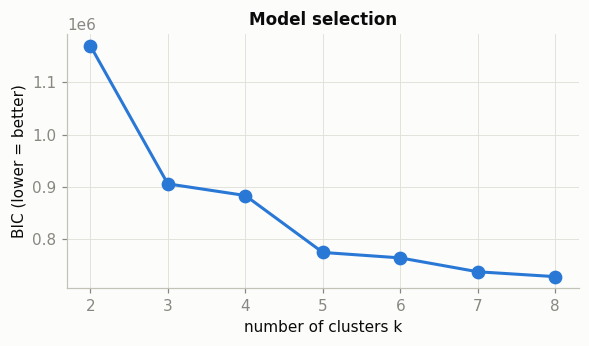

In [16]:
FEATURES = ["excess", "crest", "gap"]
sample = clean[FEATURES].sample(200_000, random_state=SEED)
scaler = StandardScaler().fit(sample)
Z = scaler.transform(sample)

ks = range(2, 9)
bic = [GaussianMixture(k, random_state=SEED, n_init=2).fit(Z).bic(Z) for k in ks]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(ks), bic, "o-", color=BLUE, lw=2, ms=8)
ax.set_xlabel("number of clusters k"); ax.set_ylabel("BIC (lower = better)")
ax.set_title("Model selection"); plt.show()

BIC keeps falling as *k* grows. With 200,000 points the model can almost always justify another cloud, so BIC alone doesn't pick a clear winner. That is common with large datasets. We therefore choose **k = 5**, the point where the curve starts to flatten, *and* the point at which each cluster still has a clean physical interpretation. Any choice here should be defended, and the defense comes in Section 6, where we check the clusters against raw data the model never saw.

To make the notebook reproducible, clusters are **named by rule from their median features**, never by hard-coded cluster numbers, which can change between runs:

In [17]:
K = 5
gmm = GaussianMixture(K, random_state=SEED, n_init=5).fit(Z)
clean["cluster_id"] = gmm.predict(scaler.transform(clean[FEATURES]))

prof = clean.groupby("cluster_id")[FEATURES].median()
names = {prof["excess"].idxmin(): "noise"}
names[prof.drop(index=list(names))["crest"].idxmax()] = "impulsive"
rest = prof.drop(index=list(names)).sort_values("excess")
names[rest.index[0]] = "weak signal"
strong = rest.iloc[1:].sort_values("gap")
names[strong.index[0]] = "strong, steady"
names[strong.index[1]] = "strong, bursty"

CLUSTERS = ["noise", "weak signal", "strong, steady", "strong, bursty", "impulsive"]
clean["cluster"] = pd.Categorical(clean["cluster_id"].map(names), categories=CLUSTERS)

summary = clean.groupby("cluster", observed=True)[FEATURES].median()
summary["share_%"] = clean["cluster"].value_counts(normalize=True).reindex(CLUSTERS) * 100
summary

,excess,crest,gap,share_%
cluster,,,,
noise,0.00,13.00,1.62,13.04
weak signal,4.75,18.94,3.31,20.92
"strong, steady",20.44,20.34,7.38,51.22
"strong, bursty",29.38,22.44,16.06,10.72
impulsive,2.75,29.97,2.81,4.10


And the mix of clusters at each sensor (% of that sensor's captures):

In [18]:
(pd.crosstab(clean["sensor"], clean["cluster"], normalize="index") * 100).round(1)

cluster,noise,weak signal,"strong, steady","strong, bursty",impulsive
sensor,,,,,
NIT,13.3,1.2,76.1,7.7,1.7
HU,11.9,1.9,71.6,12.3,2.4
CBBT-Omni,13.2,68.7,10.9,0.0,7.2
CBBT-Directional,14.1,62.3,19.8,0.0,3.8
Midway,19.5,3.8,27.1,45.0,4.6
Catalina-Omni,8.0,67.8,7.0,0.0,17.3
Catalina-Directional,10.5,21.7,65.3,0.0,2.5
GMM,11.0,8.2,80.3,0.1,0.5


The mix matches the Section 4 map. Sites near dense deployments (Norfolk, Boulder, Catalina-Directional) are mostly **strong, steady**. The water-side CBBT sensors and Catalina's omni antenna are mostly **weak signal**. **Strong, bursty** is almost entirely a Midway phenomenon: 45% of its captures, plus some at Norfolk. **Impulsive** is rare everywhere except Catalina-Omni.

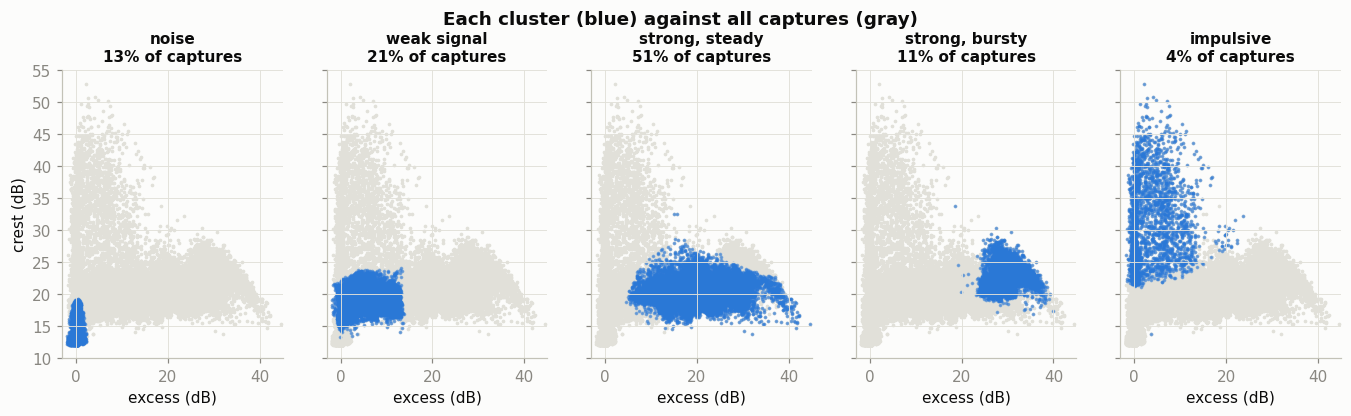

In [19]:
pts = clean.sample(60_000, random_state=SEED)
fig, axes = plt.subplots(1, 5, figsize=(15, 3.4), sharex=True, sharey=True)
for ax, c in zip(axes, CLUSTERS):
    ax.scatter(pts["excess"], pts["crest"], s=2, color=GRID, rasterized=True)
    p = pts[pts["cluster"] == c]
    ax.scatter(p["excess"], p["crest"], s=2, color=BLUE, alpha=0.5, rasterized=True)
    ax.set_title(f"{c}\n{len(p) / len(pts):.0%} of captures", fontsize=10)
    ax.set_xlabel("excess (dB)")
axes[0].set_ylabel("crest (dB)")
axes[0].set_xlim(-3, 45); axes[0].set_ylim(10, 55)
fig.suptitle("Each cluster (blue) against all captures (gray)", fontweight="bold", y=1.04)
plt.show()

Physics gives each cluster a clear reading:

* **noise**: excess ≈ 0, crest ≈ 13 dB, gap ≈ 1.6 dB. These are the Section 3 theory values; the model found them without being told.
* **weak signal**: about 5 dB above the floor, with a modest crest. Most likely distant base stations.
* **strong, steady**: about 20 dB above the floor. Nearby base stations.
* **strong, bursty**: the loudest cluster (about 29 dB) with a very large mean–median gap (16 dB). Most of the energy arrives in part of each frame, as with a very close LTE/5G base station whose transmit and listen slots differ hugely in power.
* **impulsive**: low average power but an extremely high crest. Something delivers very short, very strong pulses. **Pulsed radar is the textbook source**, though other interference can look similar.

### Where does the impulsive cluster show up?

If "impulsive" really picks out incumbent radar, it should show up *outside* the commercial band too, where CBSDs can't be, and more at the coastal sites near Navy bases than in Boulder.

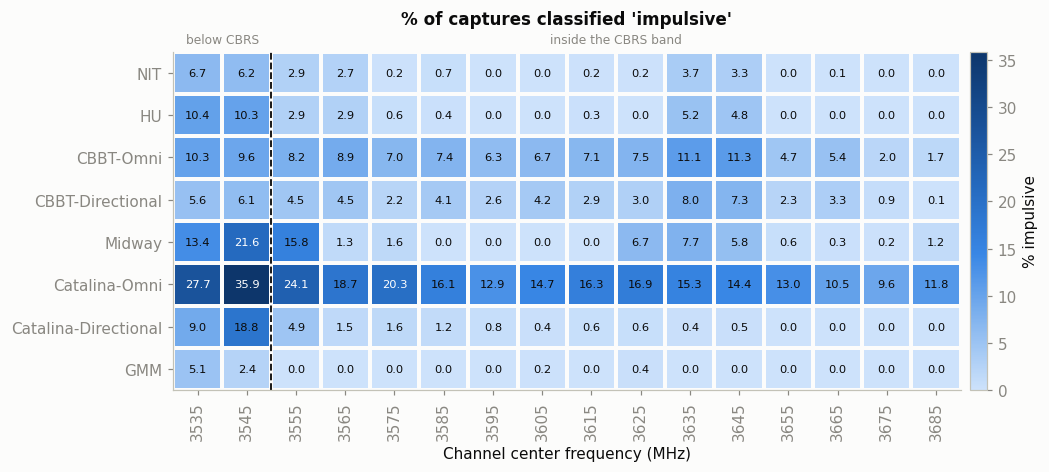

In [20]:
imp = (clean.assign(imp=clean["cluster"] == "impulsive")
            .groupby(["sensor", "freq_mhz"], observed=True)["imp"].mean().unstack() * 100)
channel_heatmap(imp, "% of captures classified 'impulsive'", "% impulsive", fmt="{:.1f}")

Mostly yes, with one caveat:

* **Every sensor has more impulsive captures below the band (3535/3545 MHz)** than in a typical in-band channel, and CBSDs aren't allowed there.
* **Catalina-Omni sees them most**: 17% of captures, on every channel. It sits on a mountaintop with an all-around view of the ocean off Southern California, where the Navy operates. Its directional antenna, a narrow 15° beam, sees far fewer (2.5%), which suggests the source is outside that beam.
* **Boulder (GMM), far from any coast, shows almost none inside CBRS but some (2–5%) below the band.** Radars operate below 3550 MHz inland too, so ship-borne radar can't be the whole story.

The overall pattern is hard to explain with commercial equipment and easy to explain with pulsed radar. It is still an *inference from statistics*: confirming a specific radar would need independent records, such as ESC detections or DPA activation logs.

## 6. Opening the raw files: independent validation

The clusters came from three summary numbers. The raw sensor files contain far richer data: a 400-point power-vs-time trace, a spectrum, and more, for every capture. We have raw files for **Catalina-Omni on four days in March**. We use them to (1) check the file format and (2) test the clusters against evidence the model never saw.

**File structure** (manual Section 3): a daily `.zip` → one `.sigmf` file per sweep (itself a tar archive) → a `.sigmf-meta` JSON metadata file plus a `.sigmf-data` file. The data file is an LZMA-compressed array of 16-bit floats holding all 18 channels back to back.

### Integrity check: does the file layout match the documentation?

The manual (Table 4) says each channel occupies **5,560** values, giving 100,080 per file. Let's check that, and also check the power values against the per-channel averages the sensor stored in its own metadata. A mismatch here would quietly corrupt every result built on the raw data.

In [21]:
# read_sigmf(), and `meta`/`arr` for the first Catalina-Omni sweep, were loaded in Section 3.
def db_mean(x):
    # Average powers in linear units (mW), then convert back to dBm
    return 10 * np.log10(np.nanmean(10 ** (np.asarray(x) / 10)))

print(f"Values in file: {arr.size:,}  (manual: 18 × 5560 = {18 * 5560:,};  18 × 5561 = {18 * 5561:,})")

stored = np.array(meta["global"]["ntia-nasctn-sea:mean_channel_powers"])
check = pd.DataFrame({
    stride: [db_mean(arr[c * stride + 1650: c * stride + 2050]) for c in range(18)]  # mean power-vs-time block
    for stride in (5560, 5561)}, index=[3535 + 10 * c for c in range(18)])
err = check.sub(stored, axis=0).abs()
print("Worst disagreement with the sensor's own stored channel power:")
print(err.max().round(3).rename(lambda s: f"stride {s}").to_string())

Values in file: 100,098  (manual: 18 × 5560 = 100,080;  18 × 5561 = 100,098)
Worst disagreement with the sensor's own stored channel power:
stride 5560    3.35
stride 5561    0.03


**Finding: the documentation is off by one.** Each channel actually holds **5,561 values**. The final block, the amplitude probability distribution, has 151 bins rather than 150. With the documented stride of 5,560, each channel's read starts one value later than the one before, and by the last channel the power values are off by several dB. With 5,561 they match the sensor's stored values to within rounding.

A second check: the metadata lists the six **periodic frame power** blocks (explained below) as `mean_minimum, mean_maximum, mean_mean, max_minimum, max_maximum, max_mean`. That puts the **RMS (average-detected) blocks first and the peak-detected blocks second**, the reverse of the order in Table 4. Physics settles it: a peak detector can never read below an average detector on the same signal.

In [22]:
print(json.dumps([p["series"] for p in meta["global"]["ntia-algorithm:data_products"]
                  if p["name"] == "Periodic Frame Power"][0]))
blocks = {start: np.nanmedian([np.nanmean(arr[c * 5561 + start: c * 5561 + start + 560]) for c in range(18)])
          for start in range(2050, 5410, 560)}
print("Median level of each 560-value block (dBm):", {k: round(v, 1) for k, v in blocks.items()})

["mean_minimum", "mean_maximum", "mean_mean", "max_minimum", "max_maximum", "max_mean"]
Median level of each 560-value block (dBm): {2050: -94.7, 2610: -88.8, 3170: -92.3, 3730: -86.9, 4290: -79.4, 4850: -83.5}


The last three blocks (starting at 3730, 4290, 4850) sit clearly higher, so they are the peak-detected ones, matching the metadata order. With both corrections the loader is straightforward:

In [23]:
STRIDE = 5561
BLOCKS = {                      # offsets within one channel, verified above
    "pvt_max":       (1250, 1650),   # peak power per 10 ms, 400 points over 4 s
    "pvt_mean":      (1650, 2050),   # average power per 10 ms
    "pfp_rms_mean":  (3170, 3730),   # periodic frame power, RMS detector, mean over frames
    "pfp_peak_max":  (4290, 4850),   # periodic frame power, peak detector, max over frames
}

def load_dayblock(path):
    rows = []
    with zipfile.ZipFile(path) as z:
        for name in sorted(n for n in z.namelist() if n.endswith(".sigmf")):
            meta, arr = read_sigmf(z.read(name))
            if arr.size != 18 * STRIDE:
                print(f"skipping {name}: {arr.size} values"); continue
            for c, cap in enumerate(meta["captures"]):
                block = arr[c * STRIDE:(c + 1) * STRIDE]
                row = {"time": pd.Timestamp(cap["core:datetime"]), "freq_mhz": cap["core:frequency"] / 1e6}
                row.update({k: block[a:b].copy() for k, (a, b) in BLOCKS.items()})
                rows.append(row)
    return pd.DataFrame(rows)

raw = pd.concat([load_dayblock(p) for p in sorted(DATA.glob("*_Catalina-Omni.zip"))], ignore_index=True)
print(f"{len(raw):,} channel captures from {raw['time'].dt.date.nunique()} days")

29,430 channel captures from 4 days


### Joining raw captures to their cluster labels

Each raw capture's timestamp matches the `time` column of a summary row exactly, so the join is a simple merge. We keep only the 16 channels analysed above. Overloaded captures were removed in Section 2 and have no label, so we report how many matched and check that every miss is explained.

In [24]:
cat = clean.loc[clean["sensor"] == "Catalina-Omni", ["time", "freq_mhz", "in_band", "cluster", "excess", "crest", "gap"]]
joined = raw[raw["freq_mhz"] <= 3685].merge(cat, on=["time", "freq_mhz"], how="left", validate="one_to_one")
print(f"Matched {joined['cluster'].notna().mean():.1%} of raw captures to a labelled summary row")
overloaded = df.loc[(df["sensor"] == "Catalina-Omni") & df["overload"], ["time", "freq_mhz"]]
print(f"Unmatched captures that were overload-flagged: "
      f"{joined[joined['cluster'].isna()].merge(overloaded, on=['time', 'freq_mhz']).shape[0]:,} "
      f"of {joined['cluster'].isna().sum():,}")
joined = joined.dropna(subset=["cluster"])

Matched 87.3% of raw captures to a labelled summary row
Unmatched captures that were overload-flagged: 3,312 of 3,312


### What each cluster looks like up close

Two raw data products are especially revealing:

* **Power vs time (PVT):** peak and average power in each 10 ms slice across the 4 s capture.
* **Periodic frame power (PFP):** the capture is cut into 400 frames of 10 ms each. The frames are stacked and summarized at each of 560 positions within the frame, a resolution of 17.9 µs. Anything that repeats on a 10 ms rhythm or a divisor of it, such as a cellular radio frame, stands out sharply. Random or unsynchronized energy smears flat.

Below is a representative capture from three clusters: the one closest to its cluster's median excess and crest factor.

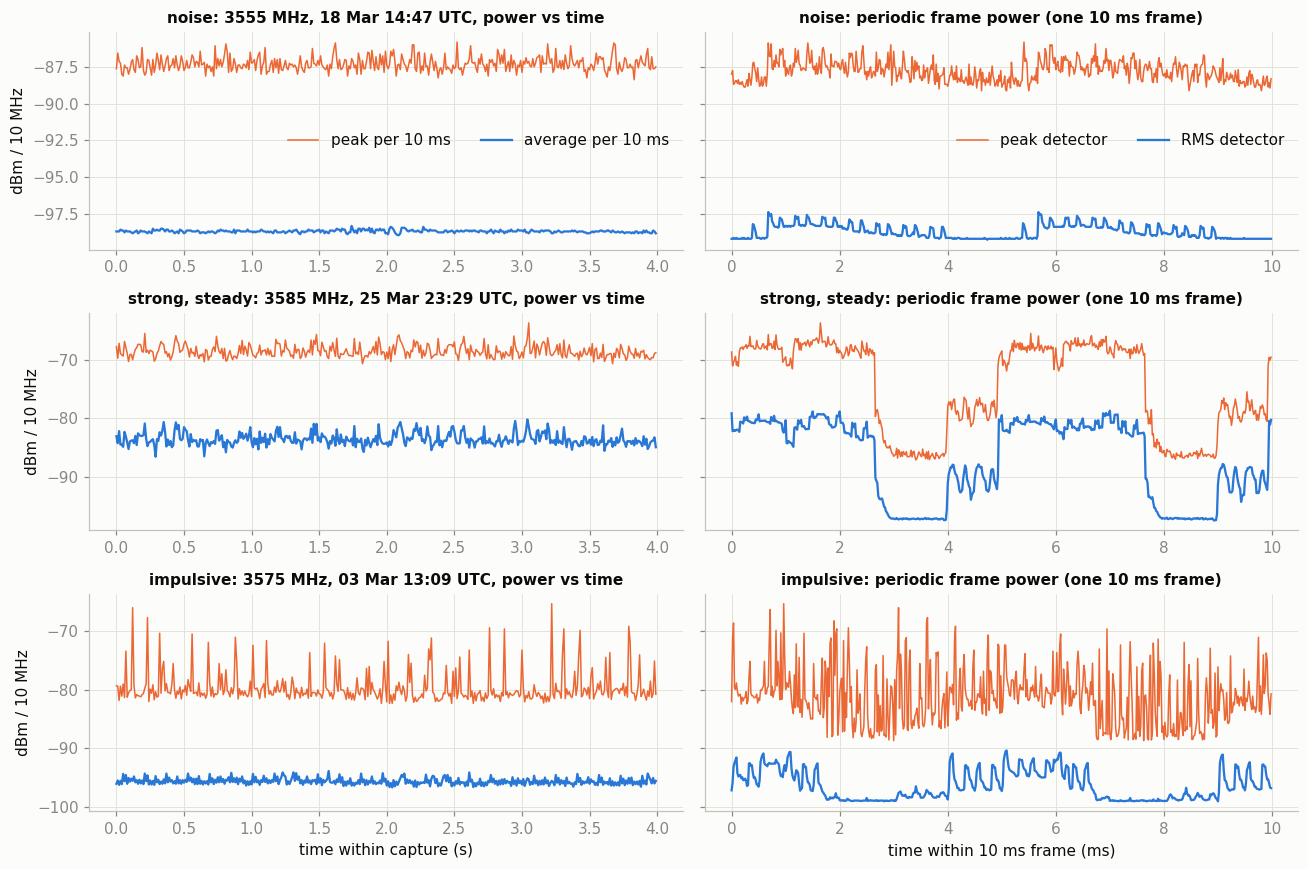

In [25]:
def typical(c):
    # The in-band capture closest to the cluster's overall median excess and crest
    d = joined[(joined["cluster"] == c) & joined["in_band"]]
    dist = ((d[["excess", "crest"]] - summary.loc[c, ["excess", "crest"]]) ** 2).sum(axis=1)
    return d.loc[dist.idxmin()]

t_pvt = np.arange(400) * 0.01
t_pfp = np.arange(560) * 10 / 560
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharey="row")
for row_axes, c in zip(axes, ["noise", "strong, steady", "impulsive"]):
    r = typical(c)
    ax = row_axes[0]
    ax.plot(t_pvt, r["pvt_max"], color=ORANGE, lw=1, label="peak per 10 ms")
    ax.plot(t_pvt, r["pvt_mean"], color=BLUE, lw=1.5, label="average per 10 ms")
    ax.set_title(f"{c}: {r['freq_mhz']:.0f} MHz, {r['time']:%d %b %H:%M} UTC, power vs time", fontsize=10)
    ax = row_axes[1]
    ax.plot(t_pfp, r["pfp_peak_max"], color=ORANGE, lw=1, label="peak detector")
    ax.plot(t_pfp, r["pfp_rms_mean"], color=BLUE, lw=1.5, label="RMS detector")
    ax.set_title(f"{c}: periodic frame power (one 10 ms frame)", fontsize=10)
    row_axes[0].set_ylabel("dBm / 10 MHz")
axes[0, 0].legend(loc="center right", ncol=2); axes[0, 1].legend(loc="center right", ncol=2)
axes[2, 0].set_xlabel("time within capture (s)"); axes[2, 1].set_xlabel("time within 10 ms frame (ms)")
plt.tight_layout(); plt.show()

* **noise**: flat, just receiver hiss. The peak detector sits about 11 dB above the average, as expected for noise. The frame view shows a faint ripple of about 1 dB: even an "empty" channel carries a whisper of some distant network, too weak to matter.
* **strong, steady**: the frame view shows a crisp **on/off pattern that repeats every 5 ms**. That is the hallmark of a 4G/5G base station using time-division duplexing (TDD), which alternates between downlink (tower transmits) and uplink (phones transmit) on a fixed schedule.
* **impulsive**: the average barely rises above the floor, but the peak trace is full of sharp spikes 10–20 dB above everything else. The spikes are *not* locked to the cellular frame. The RMS frame trace shows a faint TDD pattern underneath, so this is a pulsed emitter on top of a weak commercial background.

### Quantifying the 5 ms rhythm (signal processing)

To turn "looks periodic" into a number, we take the **Fourier transform** of each capture's peak PFP trace, in linear power units. We then find the strongest repetition rate and measure its **prominence**: the height of that peak relative to the median of the spectrum. A 5 ms period means 2 cycles per 10 ms frame.

The "strongly periodic" threshold is set **from the data rather than by hand**: the 99th percentile of prominence among captures the model called *noise*. By construction only 1% of pure-noise captures would pass it.

In [26]:
def frame_periodicity(pfp_dbm, max_cycles=100):
    x = 10 ** (np.asarray(pfp_dbm, float) / 10)
    x = np.nan_to_num(x - np.nanmean(x))
    spec = np.abs(np.fft.rfft(x)) ** 2
    k = int(np.argmax(spec[1:max_cycles])) + 1          # cycles per 10 ms frame
    return 10 / k, spec[k] / np.median(spec[1:max_cycles])

res = joined["pfp_peak_max"].apply(frame_periodicity)
joined["period_ms"] = [round(p, 3) for p, _ in res]
joined["prominence"] = [q for _, q in res]

THRESH = joined.loc[joined["cluster"] == "noise", "prominence"].quantile(0.99)
joined["tdd_5ms"] = (joined["period_ms"] == 5.0) & (joined["prominence"] > THRESH)
print(f"Prominence threshold (99th pct of noise captures): {THRESH:.0f}")

val = (joined.groupby("cluster", observed=True)
             .agg(captures=("tdd_5ms", "size"), pct_with_5ms_TDD_rhythm=("tdd_5ms", "mean"),
                  median_prominence=("prominence", "median")))
val["pct_with_5ms_TDD_rhythm"] *= 100
val

Prominence threshold (99th pct of noise captures): 331


,captures,pct_with_5ms_TDD_rhythm,median_prominence
cluster,,,
noise,1882,0.00,7.70
weak signal,13682,94.85,980.92
"strong, steady",1887,91.63,1116.07
impulsive,5397,0.15,8.76


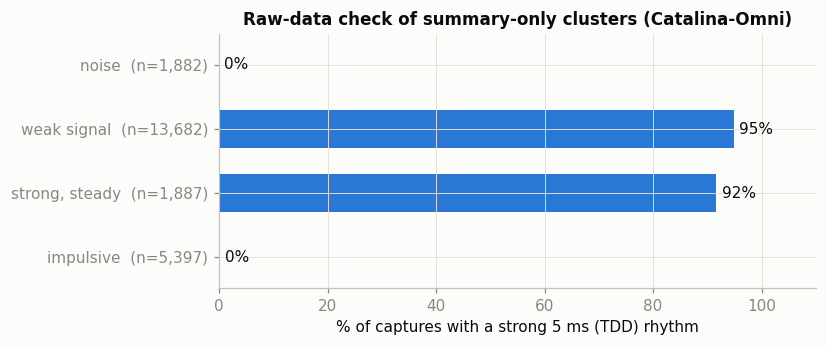

In [27]:
shown = val[val["captures"] >= 30]            # too few captures to say anything otherwise
fig, ax = plt.subplots(figsize=(7, 3))
y = np.arange(len(shown))
ax.barh(y, shown["pct_with_5ms_TDD_rhythm"], color=BLUE, height=0.6)
for yi, v in zip(y, shown["pct_with_5ms_TDD_rhythm"]):
    ax.text(v + 1, yi, f"{v:.0f}%", va="center", color=INK)
ax.set_yticks(y, [f"{c}  (n={n:,})" for c, n in shown["captures"].items()]); ax.invert_yaxis(); ax.set_xlim(0, 110)
ax.set_xlabel("% of captures with a strong 5 ms (TDD) rhythm")
ax.set_title("Raw-data check of summary-only clusters (Catalina-Omni)")
plt.show()

This is the key validation. **The model never saw the raw frame data, yet its clusters line up with an independent physical signature:**

* **95% of "weak signal" and 92% of "strong, steady" captures** carry the 5 ms TDD rhythm of a commercial base station.
* **"Noise" carries none**, which is true by construction of the threshold.
* **"Impulsive" carries almost none (0.15%)**, so its dominant energy is not cellular.
* **"Strong, bursty" never occurs at Catalina**, so this raw data can't test it. That will need raw files from Midway.

Three cheap summary numbers are enough to separate commercial activity from something else. That matters in practice: the monthly summaries are small and easy to scan, and they can point to *which* raw files are worth pulling.

## 7. Did anything change from March to April?

One goal of the SEA program is to **track the spectrum environment over time**. As a first step, we compare each sensor's average **in-band excess power** between the two months. We saw in Section 4 that "% of time above 3 dB" saturates near 100% at most sites, so it can't show growth there. Excess in dB still can.

We apply the same rigor as before. Compute one value **per day**, then bootstrap the difference in monthly means by resampling days within each month. If the 95% interval excludes zero, the change is larger than normal day-to-day variation.

In [28]:
daily_lvl = (inband.assign(day=inband["time"].dt.date)
                   .groupby(["sensor", "month", "day"], observed=True)["excess"].mean().reset_index())

rng = np.random.default_rng(SEED)
rows = []
for s in SENSOR_ORDER:
    m = [daily_lvl.loc[(daily_lvl["sensor"] == s) & (daily_lvl["month"] == mo), "excess"].to_numpy()
         for mo in ("2025-03", "2025-04")]
    boots = [rng.choice(m[1], len(m[1])).mean() - rng.choice(m[0], len(m[0])).mean() for _ in range(2000)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append((s, m[0].mean(), m[1].mean(), m[1].mean() - m[0].mean(), lo, hi))
change = pd.DataFrame(rows, columns=["sensor", "March_dB", "April_dB", "change_dB", "ci_low", "ci_high"]).set_index("sensor")
change["significant"] = (change["ci_low"] > 0) | (change["ci_high"] < 0)
change.round(2)

,March_dB,April_dB,change_dB,ci_low,ci_high,significant
sensor,,,,,,
NIT,22.96,23.57,0.61,-0.08,1.27,False
HU,24.16,24.87,0.71,0.21,1.19,True
CBBT-Omni,4.30,4.44,0.14,-0.45,0.74,False
CBBT-Directional,5.40,5.44,0.04,-0.54,0.65,False
Midway,21.01,23.14,2.13,1.25,2.93,True
Catalina-Omni,8.10,8.71,0.61,0.42,0.78,True
Catalina-Directional,13.51,15.22,1.71,1.41,1.98,True
GMM,16.84,17.07,0.23,-0.00,0.48,False


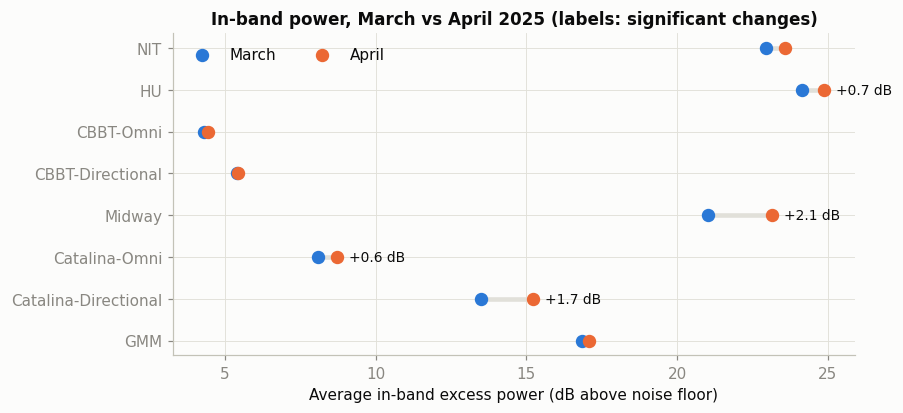

In [29]:
fig, ax = plt.subplots(figsize=(8, 3.8))
y = np.arange(len(change))
ax.hlines(y, change["March_dB"], change["April_dB"], color=GRID, lw=3)
ax.scatter(change["March_dB"], y, color=BLUE, s=60, zorder=3, label="March")
ax.scatter(change["April_dB"], y, color=ORANGE, s=60, zorder=3, label="April")
for yi, (_, r) in zip(y, change.iterrows()):
    if r["significant"]:
        ax.annotate(f"{r['change_dB']:+.1f} dB", (max(r["March_dB"], r["April_dB"]), yi),
                    xytext=(8, 0), textcoords="offset points", va="center", color=INK, fontsize=9)
ax.set_yticks(y, change.index); ax.invert_yaxis()
ax.set_xlabel("Average in-band excess power (dB above noise floor)")
ax.set_title("In-band power, March vs April 2025 (labels: significant changes)")
ax.legend(loc="upper left", ncol=2)
plt.show()

Four sensors show statistically significant increases, but two of those are small (+0.6 and +0.7 dB). **Two stand out, both in Southern California: Midway (+2.1 dB) and Catalina-Directional (+1.7 dB)**, with intervals well clear of zero. Changes like these have ordinary explanations, such as a new or re-configured base station nearby, or the SAS granting more power or channels. They are the kind of shift this monitoring should surface for follow-up.

Two cautions:
* We ran 8 tests at the 95% level, so about 0.4 false alarms would be expected by chance. The small changes deserve less weight than the large ones.
* Two months can't separate a lasting trend from a one-off or seasonal change.

## 8. Conclusions, limitations and next steps

### What we learned
1. **Check the data before trusting it.** Physics gave exact expectations for pure noise, and the data met them. The same checks exposed two errors in the documented raw-file layout and a sensor artifact at the top of the band. Each would have silently skewed results.
2. **The CBRS band is heavily and steadily used by commercial 4G/5G** at every site, with a modest daily traffic cycle. Each site has its own channel fingerprint, as expected from SAS-coordinated sharing.
3. **Three summary statistics carry real physical information.** An unsupervised Gaussian mixture on excess, crest and gap found noise, commercial and impulsive classes, and independent raw-data evidence (the 5 ms TDD frame) confirmed them.
4. **Impulsive, radar-like activity is real and structured.** It concentrates below the commercial band and at coastal sites, and is strongest at Catalina. The HU waterfall also shows channels switching off together for hours, which is what the sharing system is designed to do when an incumbent appears.
5. **The environment is changing measurably**: Midway and Catalina-Directional got about 2 dB louder in a month.

### Limitations (being honest about what this analysis can't show)
* **Two months of summaries, and raw data for one sensor on four days.** Seasonal effects and other sites' raw behavior are untested.
* **The clusters are not ground truth.** "Impulsive ⇒ radar" is a well-supported *hypothesis*. Confirming it needs independent records, such as ESC detections, DPA activations or Navy schedules.
* **The noise floor is treated as constant over two months.** It depends on calibration and temperature, and a per-day floor would be more precise.
* **Overloaded captures were excluded.** They are rare (0–5% by site) but they are *not random*: they happen when a very strong signal, often the impulsive kind, is present. Impulsive activity is therefore somewhat **under-counted**.
* **Two filter-edge channels (3695/3705 MHz) were excluded** because their noise floor is raised by the sensor itself. We only verified this from Catalina's calibration data.

### Next steps
1. Add the **amplitude probability distribution (APD)** and PSD shape from the raw files as features. The manual's Appendix A shows the APD separates radar from LTE especially well.
2. Build a small **labeled set** from known DPA activation events and train a supervised classifier. Use the GMM clusters as a baseline.
3. Package `load_summaries` and `load_dayblock` into a tested module, and run this pipeline monthly to produce an automated trend report.
4. Report the **Table 4 layout discrepancies** (5,561-value stride; PFP block order) to the data manual's authors.